# Chapter 17 Lab: Image Preprocessing (Python)

This lab accompanies Chapter 17, "Image Preprocessing". Real preprocessing runs inside packages like SPM, FSL, and fMRIPrep — here we simulate the *concepts* behind four key steps so you can see exactly what each one fixes and what it costs: (1) head motion and nuisance regression, (2) slice-timing offsets, (3) smoothing-kernel tradeoffs, and (4) high-pass filter design for drift removal.

**How to run this notebook:** it uses only numpy, scipy, and matplotlib on simulated data, so it runs in the browser (JupyterLite/Pyodide), on [Colab](https://colab.research.google.com/), or locally. Each cell takes at most a few seconds. Run cells top to bottom. See the [chapter page](../ch17-image-preprocessing.md) for the concepts.


**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal
from scipy.linalg import pinv

rng = np.random.default_rng(17)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False})


## Lab 1 — Head motion: realignment parameters as nuisance regressors

Realignment estimates six rigid-body parameters per volume: translations in $x, y, z$ (mm) and rotations roll, pitch, yaw (radians). These parameter time courses are saved by every preprocessing package (e.g., SPM's `rp_*.txt` files) and are routinely included as nuisance covariates in the GLM.

We simulate a 200-volume run (TR = 1 s) in which the head drifts slowly (a random walk) and makes one sudden jerk. The voxel's signal is a mix of "neural" fluctuations, motion-coupled artifact, and thermal noise — so we know exactly how much variance motion is responsible for, and we can check how much of it the realignment parameters recover.


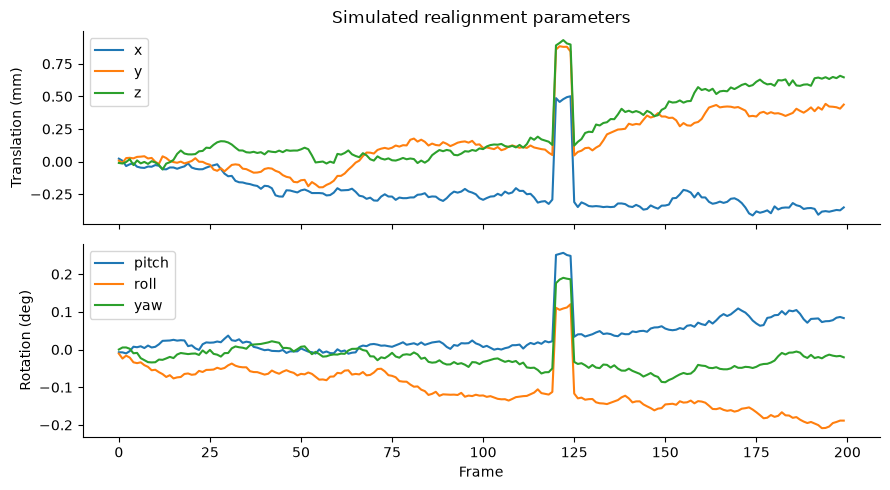

In [2]:
n, TR = 200, 1.0

# --- Six motion parameters: slow random-walk drift + one sudden jerk
mp = np.cumsum(0.02 * rng.standard_normal((n, 6)), axis=0)
mp[:, 3:] *= 0.005                      # rotations are small (radians)
mp[120:125, :3] += 0.8                  # 0.8 mm translation jerk at frame 120
mp[120:125, 3:] += 0.004                # with a small rotation component

# --- Voxel time series: neural signal + motion-coupled artifact + noise
neural = signal.lfilter([1.0], [1.0, -0.5, -0.1], rng.standard_normal(n))
motion_weights = np.array([2.0, 1.5, 1.0, 300.0, 200.0, 100.0])
motion_artifact = mp @ motion_weights
y = neural + motion_artifact + 0.5 * rng.standard_normal(n)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(mp[:, :3])
axes[0].set_ylabel("Translation (mm)"); axes[0].legend(["x", "y", "z"], loc="upper left")
axes[0].set_title("Simulated realignment parameters")
axes[1].plot(np.degrees(mp[:, 3:]))
axes[1].set_ylabel("Rotation (deg)"); axes[1].set_xlabel("Frame")
axes[1].legend(["pitch", "roll", "yaw"], loc="upper left")
plt.tight_layout()


These traces are what you should *always* plot for every run you preprocess (compare Figure 17.3 in the book). Slow drifts are normal; sudden steps like the one at frame 120 are the dangerous ones.

**How much voxel variance does motion explain?** We regress the voxel on the six parameters (plus an intercept) and compute $R^2$ — the fraction of variance the realignment parameters account for.


Variance explained by the 6 motion parameters: R^2 = 0.56


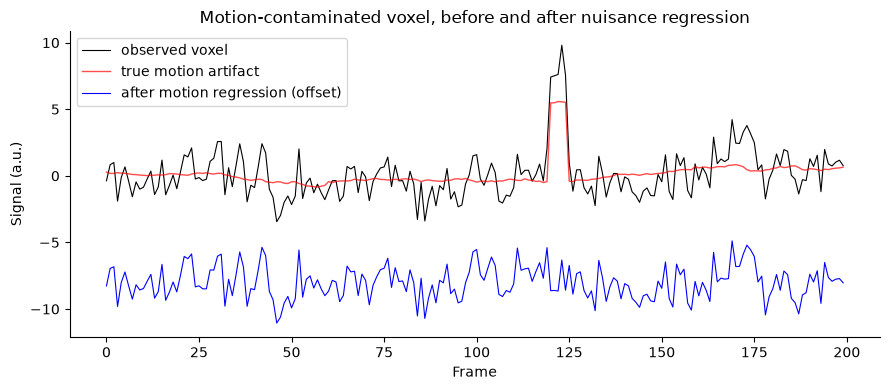

In [3]:
X = np.column_stack([mp, np.ones(n)])
beta = np.linalg.lstsq(X, y, rcond=None)[0]
resid = y - X @ beta
r2_motion = 1 - resid.var() / y.var()
print(f"Variance explained by the 6 motion parameters: R^2 = {r2_motion:.2f}")

fig, ax = plt.subplots()
ax.plot(y, "k", lw=0.8, label="observed voxel")
ax.plot(motion_artifact + y.mean() - motion_artifact.mean(), "r", lw=1,
        alpha=0.7, label="true motion artifact")
ax.plot(resid - 8, "b", lw=0.8, label="after motion regression (offset)")
ax.set_xlabel("Frame"); ax.set_ylabel("Signal (a.u.)"); ax.legend(loc="upper left")
ax.set_title("Motion-contaminated voxel, before and after nuisance regression")
plt.tight_layout()


**Framewise displacement and censoring.** FWD summarizes the six parameters into one number per frame: the sum of absolute frame-to-frame changes, with rotations converted to millimeters as arc length on a 50-mm-radius sphere,

$$\mathrm{FWD}_t = |\Delta d_x| + |\Delta d_y| + |\Delta d_z| + 50(|\Delta \alpha| + |\Delta \beta| + |\Delta \gamma|).$$

Frames exceeding a threshold (0.2–0.5 mm is typical) are censored — preferably by *spike regression*: one extra nuisance regressor per bad frame, which zeroes out that frame's influence while preserving the temporal structure of the rest of the series.


Mean FWD = 0.089 mm; 2 frames exceed 0.5 mm: [120 125]
R^2, motion params only:          0.563
R^2, motion params + spike regs:  0.566


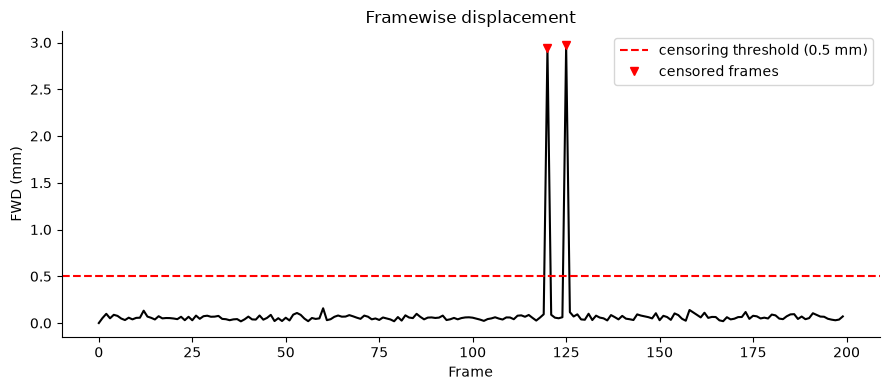

In [4]:
fwd = (np.abs(np.diff(mp[:, :3], axis=0)).sum(axis=1)
       + 50 * np.abs(np.diff(mp[:, 3:], axis=0)).sum(axis=1))
fwd = np.r_[0, fwd]                      # first frame has no predecessor
thresh = 0.5
bad = np.where(fwd > thresh)[0]
print(f"Mean FWD = {fwd.mean():.3f} mm; {bad.size} frames exceed {thresh} mm: {bad}")

# Spike regressors: one indicator column per censored frame
spikes = np.zeros((n, bad.size))
spikes[bad, np.arange(bad.size)] = 1

X2 = np.column_stack([mp, spikes, np.ones(n)])
resid2 = y - X2 @ np.linalg.lstsq(X2, y, rcond=None)[0]
print(f"R^2, motion params only:          {r2_motion:.3f}")
print(f"R^2, motion params + spike regs:  {1 - resid2.var() / y.var():.3f}")

fig, ax = plt.subplots()
ax.plot(fwd, "k")
ax.axhline(thresh, color="r", ls="--", label=f"censoring threshold ({thresh} mm)")
ax.plot(bad, fwd[bad], "rv", label="censored frames")
ax.set_xlabel("Frame"); ax.set_ylabel("FWD (mm)"); ax.legend()
ax.set_title("Framewise displacement")
plt.tight_layout()


**Interpretation.** The six realignment parameters soak up most of the motion-related variance, and spike regressors mop up the residual effect of the jerk. In real data motion also leaves *spin-history* artifacts that realignment cannot fix — which is why prevention (padding, coaching, tactile feedback) plus conservative censoring beats aggressive exclusion. Remember the selection-bias warning from the chapter: motion correlates with age, BMI, and clinical status, so excluding many participants for motion can bias your sample.


## Lab 2 — Slice-timing offsets and interpolation

Slices are acquired at different moments within each TR, but analysis treats each volume as a snapshot. With TR = 2 s and 20 slices acquired **interleaved** (odd slices first, then even), two anatomically adjacent slices can be sampled almost a full second apart.

We simulate a "true" continuous BOLD response shared by voxels in three slices — bottom (slice 0), middle (slice 10), and top (slice 19) — and sample each voxel at its actual acquisition times. Then we apply slice-timing correction by interpolating every series to the reference slice's acquisition times.


In [5]:
def double_gamma_hrf(t, a1=6, a2=16, b1=1, b2=1, c=1/6):
    """Canonical double-gamma HRF evaluated at times t (s)."""
    from scipy.special import gamma as G
    h = (t**(a1-1) * b1**a1 * np.exp(-b1*t) / G(a1)
         - c * t**(a2-1) * b2**a2 * np.exp(-b2*t) / G(a2))
    h[t < 0] = 0
    return h

TR, n_vol, n_slices = 2.0, 100, 20
dt = 0.05
t_hi = np.arange(0, n_vol * TR, dt)

# Continuous BOLD: events every 24 s convolved with the HRF
onsets = np.arange(6, n_vol * TR - 20, 24)
stim = np.zeros_like(t_hi)
stim[(onsets / dt).astype(int)] = 1
bold = np.convolve(stim, double_gamma_hrf(np.arange(0, 32, dt)))[:t_hi.size]

# Interleaved acquisition order: slices 0,2,4,...,1,3,5,...
order = np.r_[np.arange(0, n_slices, 2), np.arange(1, n_slices, 2)]
slice_offset = np.empty(n_slices)
slice_offset[order] = np.arange(n_slices) * (TR / n_slices)

# Sample each slice's voxel at its true acquisition times
vol_times = np.arange(n_vol) * TR
picks = {"slice 0 (first)": 0, "slice 10 (middle)": 10, "slice 19 (last)": 19}
sampled = {name: np.interp(vol_times + slice_offset[s], t_hi, bold)
           for name, s in picks.items()}
for name, s in picks.items():
    print(f"{name}: acquired {slice_offset[s]:.2f} s into each TR")


slice 0 (first): acquired 0.00 s into each TR
slice 10 (middle): acquired 0.50 s into each TR
slice 19 (last): acquired 1.90 s into each TR


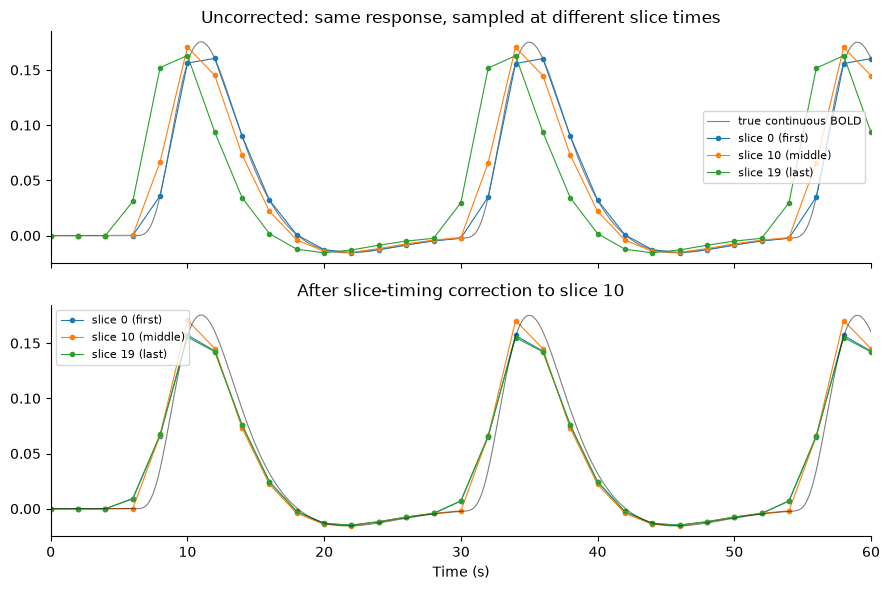

In [6]:
ref_slice = 10                                   # reference: middle of the TR
ref_offset = slice_offset[ref_slice]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t_hi, bold, "k", lw=0.8, alpha=0.5, label="true continuous BOLD")
for name, s in picks.items():
    axes[0].plot(vol_times, sampled[name], "o-", ms=3, lw=0.8, label=name)
axes[0].set_xlim(0, 60); axes[0].legend(fontsize=8)
axes[0].set_title("Uncorrected: same response, sampled at different slice times")

# Slice-timing correction: interpolate each series to the reference times
for name, s in picks.items():
    corrected = np.interp(vol_times + ref_offset,
                          vol_times + slice_offset[s], sampled[name])
    axes[1].plot(vol_times, corrected, "o-", ms=3, lw=0.8, label=name)
axes[1].plot(t_hi, bold, "k", lw=0.8, alpha=0.5)
axes[1].set_xlim(0, 60); axes[1].legend(fontsize=8)
axes[1].set_xlabel("Time (s)")
axes[1].set_title(f"After slice-timing correction to slice {ref_slice}")
plt.tight_layout()


**Why the offsets matter for estimation.** Suppose we fit each voxel with a canonical regressor built for the reference slice's timing. For a mistimed voxel, the regressor is shifted relative to the data, so the estimated amplitude (beta) is biased downward — signal leaks into the residuals.


In [7]:
# Canonical regressor built at the reference slice's timing
regressor = np.interp(vol_times + ref_offset, t_hi, bold)
regressor = (regressor - regressor.mean()) / regressor.std()

print(f"{'voxel':<20}{'beta, uncorrected':>20}{'beta, corrected':>20}")
for name, s in picks.items():
    yv = sampled[name]
    corrected = np.interp(vol_times + ref_offset,
                          vol_times + slice_offset[s], yv)
    for label, data in [("unc", yv), ("cor", corrected)]:
        d = data - data.mean()
        b = (regressor @ d) / (regressor @ regressor)
        if label == "unc":
            b_unc = b
        else:
            print(f"{name:<20}{b_unc:>20.3f}{b:>20.3f}")


voxel                  beta, uncorrected     beta, corrected
slice 0 (first)                    0.060               0.058
slice 10 (middle)                  0.061               0.061
slice 19 (last)                    0.053               0.058


**Interpretation.** With interleaved acquisition and TR = 2 s, the last-acquired slice is sampled ~1.9 s later than the first — enough to shift the sampled response visibly and bias amplitude estimates. Interpolation to a reference slice fixes most of it, at the cost of some interpolation error (and it can smear spikes and interact with motion). With TR ≤ 1 s, timing offsets shrink and many pipelines skip this step, instead shifting task *regressors* per slice or using flexible basis sets — the option recommended in the chapter for rapid acquisitions.


## Lab 3 — Smoothing kernel tradeoffs: the matched filter

Smoothing convolves the image with a 3-D Gaussian kernel described by its FWHM ($= 2\sqrt{2\ln 2}\,\sigma \approx 2.355\sigma$). Matched-filter theory says detection is optimal when the kernel matches the spatial extent of the signal: smooth too little and voxel noise dominates; smooth too much and you average true signal with null neighbors (partial-volume dilution).

We simulate a 2-D "brain slice" (2-mm voxels) with two activation blobs — one small (FWHM ≈ 7 mm) and one large (FWHM ≈ 28 mm), equal peak amplitude — plus voxelwise noise, and measure detection strength (peak z at the blob center) as a function of smoothing FWHM.


In [8]:
vox_mm = 2.0
size = 100
yy, xx = np.mgrid[0:size, 0:size]

def gauss_blob(cx, cy, sigma_vox, amp=1.0):
    return amp * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma_vox**2))

sigma_small, sigma_large = 1.5, 6.0            # in voxels
truth = (gauss_blob(28, 50, sigma_small) + gauss_blob(70, 50, sigma_large))
print(f"small blob FWHM ~ {2.355 * sigma_small * vox_mm:.0f} mm, "
      f"large blob FWHM ~ {2.355 * sigma_large * vox_mm:.0f} mm")

noise_sd = 1.0
fwhms_mm = np.arange(0, 17, 1)                  # smoothing kernels to test
n_sims = 60

z_small, z_large = [], []
for fwhm in fwhms_mm:
    sigma_vox = fwhm / 2.355 / vox_mm
    peaks_s, peaks_l, noise_sds = [], [], []
    for _ in range(n_sims):
        img = truth + noise_sd * rng.standard_normal((size, size))
        sm = ndimage.gaussian_filter(img, sigma_vox) if sigma_vox > 0 else img
        peaks_s.append(sm[50, 28]); peaks_l.append(sm[50, 70])
        noise_sds.append(sm[5:20, 5:20].std())   # background patch
    sd = np.mean(noise_sds)
    z_small.append(np.mean(peaks_s) / sd)
    z_large.append(np.mean(peaks_l) / sd)
z_small, z_large = np.array(z_small), np.array(z_large)


small blob FWHM ~ 7 mm, large blob FWHM ~ 28 mm


Best FWHM for small blob: 8 mm; for large blob: 16 mm


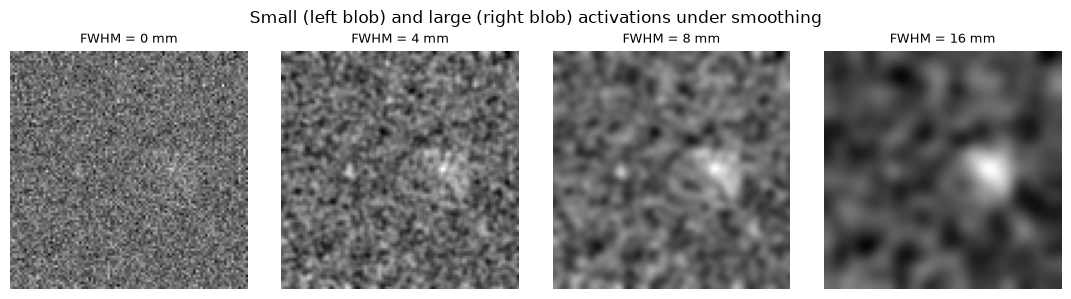

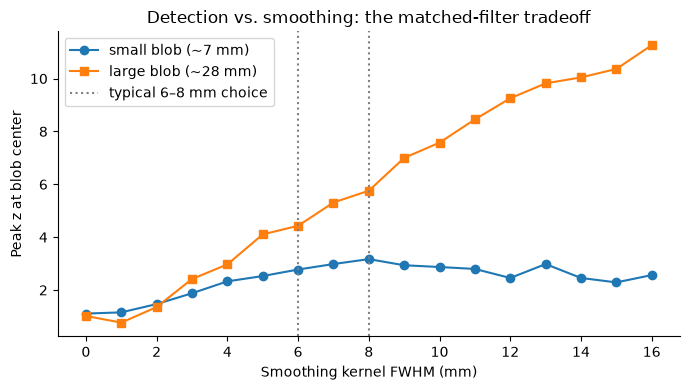

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
img = truth + noise_sd * rng.standard_normal((size, size))
for ax, fwhm in zip(axes, [0, 4, 8, 16]):
    sigma_vox = fwhm / 2.355 / vox_mm
    sm = ndimage.gaussian_filter(img, sigma_vox) if sigma_vox > 0 else img
    ax.imshow(sm, cmap="gray"); ax.set_title(f"FWHM = {fwhm} mm", fontsize=9)
    ax.axis("off")
plt.suptitle("Small (left blob) and large (right blob) activations under smoothing")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fwhms_mm, z_small, "o-", label=f"small blob (~7 mm)")
ax.plot(fwhms_mm, z_large, "s-", label=f"large blob (~28 mm)")
ax.axvline(6, color="gray", ls=":", label="typical 6–8 mm choice")
ax.axvline(8, color="gray", ls=":")
ax.set_xlabel("Smoothing kernel FWHM (mm)")
ax.set_ylabel("Peak z at blob center")
ax.legend(); ax.set_title("Detection vs. smoothing: the matched-filter tradeoff")
plt.tight_layout()

print(f"Best FWHM for small blob: {fwhms_mm[z_small.argmax()]} mm; "
      f"for large blob: {fwhms_mm[z_large.argmax()]} mm")


**Interpretation.** Each activation is best detected with a kernel near its own spatial scale: the small blob's detectability *peaks* at a small FWHM and then declines as smoothing dilutes it, while the large blob keeps gaining from heavier smoothing. A single a-priori kernel (the typical 6 or 8 mm) is a compromise — good for cortical-scale signals, costly for fine structure like the brainstem. This is also why MVPA studies analyzing fine-grained patterns often skip smoothing, and why smoothing also serves a second purpose the simulation doesn't show: making images smooth enough for Gaussian random field theory to yield accurate corrected P values.


## Lab 4 — High-pass filter design and drift removal

Scanner drift concentrates power at very low frequencies. High-pass filtering removes it — most transparently by building a set of low-frequency discrete-cosine (DCT) regressors $K_H$ up to the cutoff frequency and projecting them out with the residual-forming matrix

$$S = I - K_H K_H^{+}.$$

This is exactly how SPM's 128-s default works, and it means filtering *is* nuisance regression. A key practical principle (from the CANlab example `linear_filtering_a_timeseries.m`, github.com/canlab): do **not** sequentially filter and then regress out nuisance covariates — combine the DCT columns, motion parameters, spikes, and run intercepts into one matrix and remove them in a single step, and apply the same operation to your task regressors.


In [10]:
# Code adapted from CANlab_help_examples: linear_filtering_a_timeseries.m
TR, n, hpf = 2.0, 300, 128.0                    # cutoff in seconds

def dct_highpass_basis(n, TR, cutoff_s):
    """SPM-style DCT basis: cosines with periods longer than the cutoff."""
    k = int(np.floor(2 * n * TR / cutoff_s + 1))
    t = np.arange(n)
    return np.column_stack(
        [np.sqrt(2 / n) * np.cos(np.pi * (2 * t + 1) * j / (2 * n))
         for j in range(1, k)])

KH = dct_highpass_basis(n, TR, hpf)
S = np.eye(n) - KH @ pinv(KH)                   # residual-forming matrix
print(f"{KH.shape[1]} DCT regressors span frequencies below 1/{hpf:.0f} Hz"
      f" = {1/hpf:.4f} Hz")

# Simulated run: 30-s alternating blocks + slow drift + AR(2) noise
task = np.tile(np.r_[np.ones(15), np.zeros(15)], 10).astype(float)   # in TRs
tsec = np.arange(n) * TR
drift = 3 * np.sin(2 * np.pi * tsec / 400) + 0.004 * (tsec - tsec.mean())
ar_noise = signal.lfilter([1.0], [1.0, -0.7, -0.3], rng.standard_normal(n))
y_obs = task + drift + ar_noise

y_filt = S @ y_obs
print(f"corr(task, observed) = {np.corrcoef(task, y_obs)[0, 1]:.2f}")
print(f"corr(task, filtered) = {np.corrcoef(task, y_filt)[0, 1]:.2f}")


9 DCT regressors span frequencies below 1/128 Hz = 0.0078 Hz
corr(task, observed) = 0.18
corr(task, filtered) = 0.32


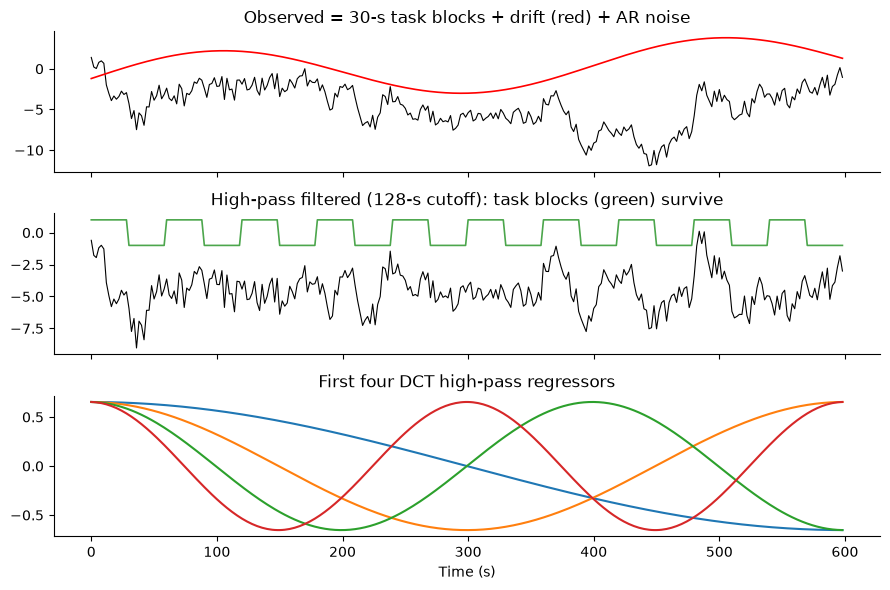

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
axes[0].plot(tsec, y_obs, "k", lw=0.8); axes[0].plot(tsec, drift, "r", lw=1.2)
axes[0].set_title("Observed = 30-s task blocks + drift (red) + AR noise")
axes[1].plot(tsec, y_filt, "k", lw=0.8)
axes[1].plot(tsec, 2 * (task - task.mean()), "g", lw=1.2, alpha=0.7)
axes[1].set_title("High-pass filtered (128-s cutoff): task blocks (green) survive")
axes[2].plot(tsec, KH[:, :4] * 8)
axes[2].set_title("First four DCT high-pass regressors")
axes[2].set_xlabel("Time (s)")
plt.tight_layout()


**When the filter eats your task.** The filter removes *everything* below the cutoff — including task signal, if your design puts power there. We measure the fraction of task variance removed, $1 - \mathrm{var}(S x_{task}) / \mathrm{var}(x_{task})$, for alternating block designs of increasing length under the 128-s default.


32-s blocks: 2% of task variance removed
64-s blocks: 43% of task variance removed


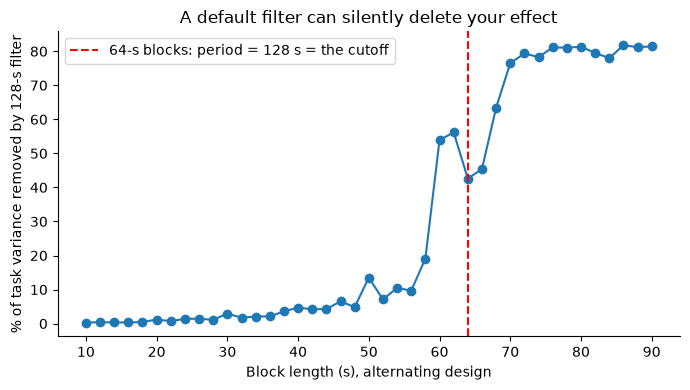

In [12]:
block_lengths = np.arange(10, 92, 2)            # seconds per block
frac_removed = []
for bl in block_lengths:
    bl_tr = int(round(bl / TR))
    cycles = int(np.ceil(n / (2 * bl_tr)))
    x = np.tile(np.r_[np.ones(bl_tr), np.zeros(bl_tr)], cycles)[:n].astype(float)
    xc = x - x.mean()
    frac_removed.append(1 - (S @ x).var() / xc.var())
frac_removed = np.array(frac_removed)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(block_lengths, 100 * frac_removed, "o-")
ax.axvline(64, color="r", ls="--",
           label="64-s blocks: period = 128 s = the cutoff")
ax.set_xlabel("Block length (s), alternating design")
ax.set_ylabel("% of task variance removed by 128-s filter")
ax.legend(); ax.set_title("A default filter can silently delete your effect")
plt.tight_layout()

i32 = np.argmin(np.abs(block_lengths - 32)); i64 = np.argmin(np.abs(block_lengths - 64))
print(f"32-s blocks: {100*frac_removed[i32]:.0f}% of task variance removed")
print(f"64-s blocks: {100*frac_removed[i64]:.0f}% of task variance removed")


**Interpretation.** Short alternating blocks sail through the filter, but as the design period approaches the 128-s cutoff the filter removes most of the task variance — with 64-s blocks (128-s period), the "correction" deletes the experiment. This matches the chapter's warning that default settings can filter out nearly all true signal from designs with alternating blocks of roughly 32 s or longer (where harmonically related power begins to overlap the stopband and losses grow steeply with block length). Always check the overlap between your design's frequencies and your filter before analyzing — and remember that whatever filter you apply to the data must also be applied to the task regressors and nuisance covariates in your model.

## Wrap-up

- Realignment parameters capture head motion and explain real variance in voxel time series; FWD summarizes them for censoring, and spike regression censors without destroying temporal structure.
- Slice-timing offsets shift sampled responses by up to nearly one TR; interpolation (or regressor-shifting) realigns them in time.
- Smoothing is a matched filter: the best kernel depends on the (unknown) signal extent, so the conventional 6–8 mm is a compromise.
- High-pass filtering is nuisance regression with DCT cosines; design your cutoff around your task frequencies, not the other way around.

Continue to [Chapter 18](../ch18-the-general-linear-model-and.md), where these cleaned-up time series meet the General Linear Model.
